In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
save_path="data_output/hvdc_utc12.csv"

hvdc = pd.read_csv("data_input/hvdc_transfer.csv")

In [3]:
hvdc.head(-1)

,Period start,Period end,Trading period,Direction,Energy transfer (GWh),Peak flow (MW),Average flow (MW)
0,01/01/2014 00:00:00,01/01/2014 00:30:00,1,Northward at Haywards,0.223,445,445
1,01/01/2014 00:30:00,01/01/2014 01:00:00,2,Northward at Haywards,0.193,386,386
2,01/01/2014 01:00:00,01/01/2014 01:30:00,3,Northward at Haywards,0.180,360,360
3,01/01/2014 01:30:00,01/01/2014 02:00:00,4,Northward at Haywards,0.183,365,365
4,01/01/2014 02:00:00,01/01/2014 02:30:00,5,Northward at Haywards,0.184,367,367
...,...,...,...,...,...,...,...
215505,25/05/2026 21:00:00,25/05/2026 21:30:00,43,Northward at Haywards,0.229,458,458
215506,25/05/2026 21:30:00,25/05/2026 22:00:00,44,Northward at Haywards,0.215,429,429
215507,25/05/2026 22:00:00,25/05/2026 22:30:00,45,Northward at Haywards,0.161,321,321
215508,25/05/2026 22:30:00,25/05/2026 23:00:00,46,Northward at Haywards,0.103,206,206


In [4]:
hvdc = hvdc[['Period start', 'Direction','Peak flow (MW)', 'Average flow (MW)']].rename(columns={
    'Period start': 'datetime',
    'Peak flow (MW)': 'peak_flow_MW',
    'Average flow (MW)': 'avg_flow_MW'
})

In [5]:
hvdc['datetime'] = pd.to_datetime(hvdc['datetime'], dayfirst=True)

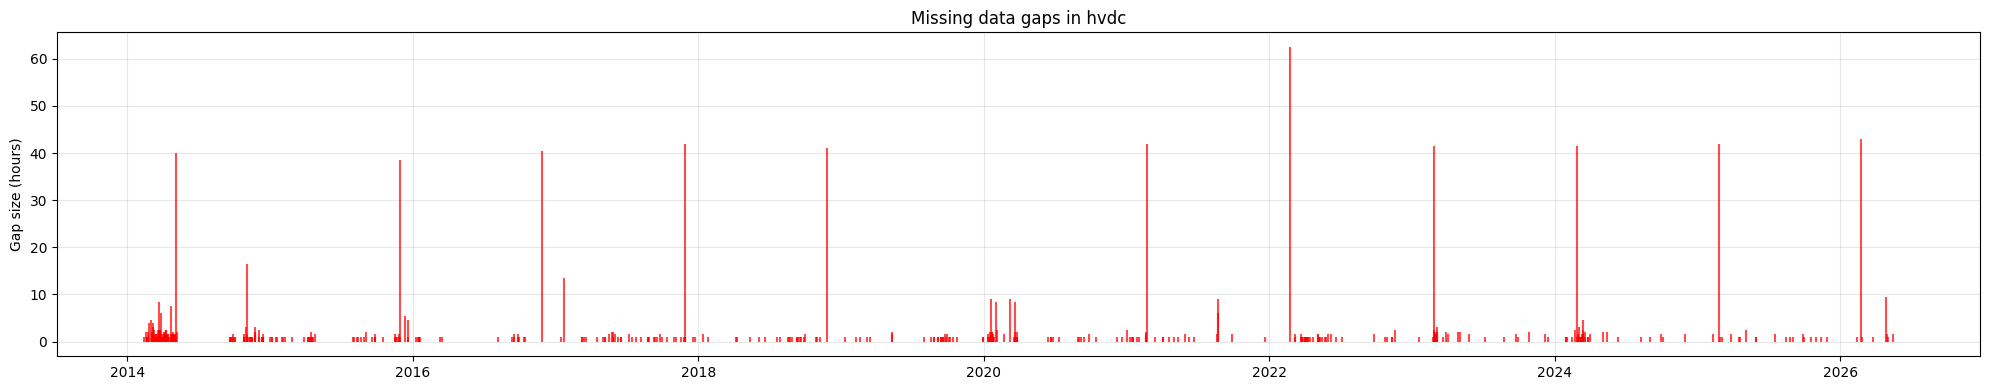

Total gaps: 485
Total missing hours: 1172.0h


In [6]:
import matplotlib.pyplot as plt

diff = hvdc['datetime'].diff()
gaps = diff[diff > pd.Timedelta('30min')]

plt.figure(figsize=(20, 4))
plt.vlines(hvdc['datetime'].iloc[gaps.index], ymin=0, ymax=gaps.dt.total_seconds()/3600, color='red', alpha=0.7)
plt.ylabel('Gap size (hours)')
plt.title('Missing data gaps in hvdc')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total gaps: {len(gaps)}")
print(f"Total missing hours: {gaps.dt.total_seconds().sum()/3600:.1f}h")

In [7]:
diff = hvdc['datetime'].diff()
small_gaps = diff[(diff > pd.Timedelta('1h')) & (diff < pd.Timedelta('10h'))]

for idx in small_gaps.index:
    start = hvdc['datetime'].iloc[idx-1]
    end = hvdc['datetime'].iloc[idx]
    print(f"{start} → {end} | {small_gaps.loc[idx]}")

2014-02-18 02:00:00 → 2014-02-18 04:00:00 | 0 days 02:00:00
2014-02-22 04:00:00 → 2014-02-22 06:00:00 | 0 days 02:00:00
2014-02-26 00:30:00 → 2014-02-26 04:30:00 | 0 days 04:00:00
2014-03-03 00:30:00 → 2014-03-03 05:00:00 | 0 days 04:30:00
2014-03-04 23:30:00 → 2014-03-05 01:30:00 | 0 days 02:00:00
2014-03-05 22:30:00 → 2014-03-06 00:00:00 | 0 days 01:30:00
2014-03-06 00:00:00 → 2014-03-06 04:00:00 | 0 days 04:00:00
2014-03-08 00:00:00 → 2014-03-08 01:30:00 | 0 days 01:30:00
2014-03-08 02:30:00 → 2014-03-08 05:30:00 | 0 days 03:00:00
2014-03-10 02:00:00 → 2014-03-10 04:30:00 | 0 days 02:30:00
2014-03-13 04:30:00 → 2014-03-13 06:00:00 | 0 days 01:30:00
2014-03-13 21:30:00 → 2014-03-13 23:00:00 | 0 days 01:30:00
2014-03-15 07:30:00 → 2014-03-15 09:00:00 | 0 days 01:30:00
2014-03-19 04:00:00 → 2014-03-19 05:30:00 | 0 days 01:30:00
2014-03-20 19:30:00 → 2014-03-20 22:00:00 | 0 days 02:30:00
2014-03-22 11:00:00 → 2014-03-22 19:30:00 | 0 days 08:30:00
2014-03-23 09:00:00 → 2014-03-23 11:30:0

In [8]:
hvdc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215511 entries, 0 to 215510
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   datetime      215511 non-null  datetime64[ns]
 1   Direction     215511 non-null  object        
 2   peak_flow_MW  215511 non-null  int64         
 3   avg_flow_MW   215511 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 6.6+ MB


In [9]:
print("=== AUTUMN 7 Apr 2024 ===")
print(hvdc[hvdc.datetime.between('2024-04-07 01:00', '2024-04-07 05:00')].datetime.tolist())

print("\n=== SPRING 29 Sep 2024 ===")
print(hvdc[hvdc.datetime.between('2024-09-29 01:00', '2024-09-29 05:00')].datetime.tolist())

=== AUTUMN 7 Apr 2024 ===
[Timestamp('2024-04-07 01:00:00'), Timestamp('2024-04-07 01:30:00'), Timestamp('2024-04-07 02:00:00'), Timestamp('2024-04-07 02:30:00'), Timestamp('2024-04-07 02:00:00'), Timestamp('2024-04-07 02:30:00'), Timestamp('2024-04-07 03:00:00'), Timestamp('2024-04-07 03:30:00'), Timestamp('2024-04-07 04:00:00'), Timestamp('2024-04-07 04:30:00'), Timestamp('2024-04-07 05:00:00')]

=== SPRING 29 Sep 2024 ===
[Timestamp('2024-09-29 01:00:00'), Timestamp('2024-09-29 01:30:00'), Timestamp('2024-09-29 03:00:00'), Timestamp('2024-09-29 03:30:00'), Timestamp('2024-09-29 04:00:00'), Timestamp('2024-09-29 04:30:00'), Timestamp('2024-09-29 05:00:00')]


In [10]:
print(hvdc.datetime.duplicated().sum())

26


In [11]:
# Step 1: handle duplicates
hvdc_dupes = hvdc[hvdc['datetime'].duplicated(keep='first')].copy()
hvdc_clean = hvdc[~hvdc['datetime'].duplicated(keep='first')].copy()

# Step 2: set index and convert to UTC+12
hvdc_clean = hvdc_clean.set_index('datetime')
hvdc_clean.index = (
    pd.to_datetime(hvdc_clean.index)
    .tz_localize('Pacific/Auckland', ambiguous='NaT', nonexistent='NaT')
    .tz_convert('Etc/GMT-12')
    .tz_localize(None)
)
hvdc_clean = hvdc_clean[hvdc_clean.index.notna()]

# Step 3: convert dupes to UTC+12 as well
hvdc_dupes = hvdc_dupes.set_index('datetime')
hvdc_dupes.index = (
    pd.to_datetime(hvdc_dupes.index)
    .tz_localize('Pacific/Auckland', ambiguous=True, nonexistent='NaT')
    .tz_convert('Etc/GMT-12')
    .tz_localize(None)
)

# Step 4: reinsert into slots that don't already exist
new_slots = hvdc_dupes.index[~hvdc_dupes.index.isin(hvdc_clean.index)]
hvdc_clean = pd.concat([hvdc_clean, hvdc_dupes.loc[new_slots]]).sort_index()

# Step 5: fill maintenance gaps with 0
hvdc_utc12 = hvdc_clean.resample('30min').asfreq().fillna(0)

# verify
print(hvdc_utc12['2024-04-07 01:00':'2024-04-07 04:00'])

                                Direction  peak_flow_MW  avg_flow_MW
datetime                                                            
2024-04-07 01:00:00  Southward at Benmore        -338.0       -169.0
2024-04-07 01:30:00  Southward at Benmore        -332.0       -166.0
2024-04-07 02:00:00                     0           0.0          0.0
2024-04-07 02:30:00                     0           0.0          0.0
2024-04-07 03:00:00  Southward at Benmore        -335.0       -335.0
2024-04-07 03:30:00  Southward at Benmore        -347.0       -347.0
2024-04-07 04:00:00  Southward at Benmore        -323.0       -323.0


In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# col = 'peak_flow_MW'
# hvdc = hvdc.set_index('datetime')

# # --- SET DATES HERE ---
# autumn_date = '2024-04-07'
# spring_date = '2024-09-29'

# # --- AUTUMN ---
# aut_start = pd.Timestamp(autumn_date) - pd.Timedelta(hours=12)
# aut_end   = pd.Timestamp(autumn_date) + pd.Timedelta(hours=12)
# aut_orig  = hvdc[aut_start:aut_end][col]
# aut_utc   = hvdc_utc12[aut_start:aut_end][col]

# # --- SPRING ---
# spr_start = pd.Timestamp(spring_date) - pd.Timedelta(hours=12)
# spr_end   = pd.Timestamp(spring_date) + pd.Timedelta(hours=12)
# spr_orig  = hvdc[spr_start:spr_end][col]
# spr_utc   = hvdc_utc12[spr_start:spr_end][col]

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8))

# # Autumn
# ax1.plot(aut_orig.index, aut_orig.values, label='original', marker='o', markersize=3)
# ax1.plot(aut_utc.index,  aut_utc.values,  label='utc+12',   marker='o', markersize=3, linestyle='--')
# ax1.axvspan(pd.Timestamp(autumn_date).replace(hour=2), pd.Timestamp(autumn_date).replace(hour=3), alpha=0.15, color='red', label='DST transition')
# ax1.set_title(f'AUTUMN — {autumn_date} (fallback)')
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
# ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
# plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# # Spring
# ax2.plot(spr_orig.index, spr_orig.values, label='original', marker='o', markersize=3)
# ax2.plot(spr_utc.index,  spr_utc.values,  label='utc+12',   marker='o', markersize=3, linestyle='--')
# ax2.axvspan(pd.Timestamp(spring_date).replace(hour=2), pd.Timestamp(spring_date).replace(hour=3), alpha=0.15, color='red', label='DST transition')
# ax2.set_title(f'SPRING — {spring_date} (spring forward)')
# ax2.xa

KeyError: "None of ['datetime'] are in the columns"

In [14]:
hvdc_utc12.head()

,Direction,peak_flow_MW,avg_flow_MW
datetime,,,
2013-12-31 23:00:00,Northward at Haywards,445.0,445.0
2013-12-31 23:30:00,Northward at Haywards,386.0,386.0
2014-01-01 00:00:00,Northward at Haywards,360.0,360.0
2014-01-01 00:30:00,Northward at Haywards,365.0,365.0
2014-01-01 01:00:00,Northward at Haywards,367.0,367.0


In [15]:
hvdc_utc12.reset_index(inplace=True)
hvdc_utc12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217346 entries, 0 to 217345
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   datetime      217346 non-null  datetime64[ns]
 1   Direction     217346 non-null  object        
 2   peak_flow_MW  217346 non-null  float64       
 3   avg_flow_MW   217346 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 6.6+ MB


In [16]:
hvdc_utc12.head()

,datetime,Direction,peak_flow_MW,avg_flow_MW
0,2013-12-31 23:00:00,Northward at Haywards,445.0,445.0
1,2013-12-31 23:30:00,Northward at Haywards,386.0,386.0
2,2014-01-01 00:00:00,Northward at Haywards,360.0,360.0
3,2014-01-01 00:30:00,Northward at Haywards,365.0,365.0
4,2014-01-01 01:00:00,Northward at Haywards,367.0,367.0


In [19]:
hvdc_utc12.describe()

,datetime,peak_flow_MW,avg_flow_MW
count,217346,217346.000000,217346.000000
mean,2020-03-13 23:15:00.000001024,279.851062,279.857255
min,2013-12-31 23:00:00,-739.000000,-739.000000
25%,2017-02-05 23:07:30,69.000000,69.000000
50%,2020-03-13 23:15:00,292.000000,292.000000
75%,2023-04-19 23:22:30,501.000000,501.000000
max,2026-05-25 23:30:00,1055.000000,1055.000000
std,NaN,300.595127,300.581443


In [ ]:
hvdc_utc12.to_csv(save_path, index=False)
print(f"✅ hvdc has been cleaned and saved under {save_path} ✅")

✅ demand has been cleaned and saved under data_output/demand_utc12.csv ✅


In [17]:
hvdc_utc12.head(50)

,datetime,Direction,peak_flow_MW,avg_flow_MW
0,2013-12-31 23:00:00,Northward at Haywards,445.0,445.0
1,2013-12-31 23:30:00,Northward at Haywards,386.0,386.0
2,2014-01-01 00:00:00,Northward at Haywards,360.0,360.0
3,2014-01-01 00:30:00,Northward at Haywards,365.0,365.0
4,2014-01-01 01:00:00,Northward at Haywards,367.0,367.0
5,2014-01-01 01:30:00,Northward at Haywards,324.0,324.0
6,2014-01-01 02:00:00,Northward at Haywards,328.0,328.0
7,2014-01-01 02:30:00,Northward at Haywards,319.0,319.0
8,2014-01-01 03:00:00,Northward at Haywards,268.0,268.0
9,2014-01-01 03:30:00,Northward at Haywards,262.0,262.0
